In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import chardet
import seaborn as sns
from textwrap import wrap

In [2]:
geneset=pd.read_csv('genesets/lim_cds_geneset.txt',header=0,sep='\t')

In [3]:
mutationmatrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.mutect2_snv.tsv.gz",sep="\t",index_col=0)
#nonsyn_mutmatrix=mutationmatrix.loc[~mutationmatrix["effect"].str.contains("synonymous_variant")].copy()
nonsense_mutmatrix=mutationmatrix.loc[mutationmatrix["effect"].str.contains("NMD_transcript_variant|stop")].copy()
test=pd.crosstab(columns=nonsense_mutmatrix.index, index=nonsense_mutmatrix.gene)

In [ ]:
#test=pd.crosstab(columns=nonsyn_mutmatrix.index, index=nonsyn_mutmatrix.gene)
#test.head()

In [3]:
tcgagenemap=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/probeMap_gencode.v23.annotation.gene.probemap",sep="\t",index_col=0)
enslist=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
print(len(enslist))#ensids
print(len(list(set(enslist))))#unique ensids
tcgaensdict=dict(zip(tcgagenemap['gene'].values.tolist(),enslist))

60498
60498


In [4]:
genesetdict={}
for c in geneset.columns:
    genesetdict[c]=list(geneset[c].dropna().values)

In [5]:
gsgenemap={}
for gs in genesetdict:
    for g in genesetdict[gs]:
        try:
            gsgenemap[g]=tcgaensdict[g]
        except:
            print(g)

CYRIB
NECTIN2
H1-0
PLPPR4
PLPP4
PLPP5
GSDME
PJVK
GSDME
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [6]:
#partial hotfix comeback
gsgenemap['PRKN']='ENSG00000185345'
gsgenemap['TOMM70']='ENSG00000196683'
gsgenemap['TUBB8B']='ENSG00000173213'
gsgenemap['H1-0']='ENSG00000189060'
gsgenemap['PLPPR4']='ENSG00000117600'
gsgenemap['PLPP4']='ENSG00000203805'
gsgenemap['PLPP5']='ENSG00000147535'
gsgenemap['CYRIB']='ENSG00000153310'
gsgenemap['NECTIN2']='ENSG00000130202'
gsgenemap['MIR3606']='ENSG00000284180'
gsgenemap['GSDME']='ENSG00000105928'
#HLADRB3,4 missing in ensembl

In [7]:
ensgeneset={}
for gs in genesetdict:
    if gs not in ensgeneset.keys():
        ensgeneset[gs]=[]
    for g in genesetdict[gs]:
        try:
            ensgeneset[gs].append(gsgenemap[g])
        except:
            print(g)

PJVK
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [56]:
mm_hgnclist=test.index.to_list()
mm_hgnclist
mm_enslist=[]
for g in mm_hgnclist:
    try:
        mm_enslist.append(tcgaensdict[g])
    except KeyError:
        print(g)
        mm_enslist.append(g)

NameError: name 'test' is not defined

In [6]:
test.index=mm_enslist
test.head()

col_0,TCGA-02-0033-01A,TCGA-02-0047-01A,TCGA-02-0055-01A,TCGA-02-2466-01A,TCGA-02-2470-01A,TCGA-02-2485-01A,TCGA-02-2486-01A,TCGA-04-1331-01A,TCGA-04-1332-01A,TCGA-04-1336-01A,...,TCGA-ZP-A9D2-01A,TCGA-ZP-A9D4-01A,TCGA-ZQ-A9CR-01A,TCGA-ZR-A9CJ-01B,TCGA-ZS-A9CD-01A,TCGA-ZS-A9CE-01A,TCGA-ZS-A9CF-01A,TCGA-ZS-A9CG-01A,TCGA-ZU-A8S4-01A,TCGA-ZX-AA5X-01A
ENSG00000121410,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000148584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000175899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000166535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000184389,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
cat_sample=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.basic_phenotype.tsv",index_col=0,sep="\t")

In [9]:
cat_sample

,program,sample_type_id,sample_type,project_id,Age at Diagnosis in Years,Gender
sample,,,,,,
TCGA-69-7978-01A,TCGA,1,Primary Tumor,TCGA-LUAD,59.000000,Male
TCGA-AR-A24Z-01A,TCGA,1,Primary Tumor,TCGA-BRCA,57.000000,Female
TCGA-D1-A103-01A,TCGA,1,Primary Tumor,TCGA-UCEC,87.000000,Female
TARGET-20-PASRLS-09A,TARGET,9,Primary Blood Derived Cancer - Bone Marrow,TARGET-AML,0.816438,Female
TARGET-20-PASARK-14A,TARGET,14,Bone Marrow Normal,TARGET-AML,15.520548,Male
...,...,...,...,...,...,...
TCGA-3G-AB0T-11A,TCGA,11,Solid Tissue Normal,TCGA-THYM,45.000000,Male
TCGA-44-6775-11A,TCGA,11,Solid Tissue Normal,TCGA-LUAD,72.000000,Female
TCGA-BJ-A0Z0-01A,TCGA,1,Primary Tumor,TCGA-THCA,55.000000,Male


In [10]:
cat_sample.dropna(inplace=True)
cat_sample.drop(cat_sample.loc[cat_sample['sample_type'].str.contains("Normal")].index,inplace=True)
cat_sdit=dict(cat_sample['project_id'])

In [11]:
can_dict={}
for s in cat_sdit:
    if cat_sdit[s] not in can_dict.keys():
        can_dict[cat_sdit[s]]=[]
        can_dict[cat_sdit[s]].append(s)
    else:
        can_dict[cat_sdit[s]].append(s)

In [11]:
for can in can_dict:
    test.loc[:,test.columns.intersection(can_dict[can])].to_csv("snv_cancer/nonsense/"+can+"_snvmat.tsv",sep="\t")

In [57]:
cn_matrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.gistic.tsv.gz",sep="\t",index_col=0)

In [58]:
cngenelist=cn_matrix.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
cn_matrix.index=cngenelist

In [ ]:
for can in can_dict:
    cn_matrix.loc[:,cn_matrix.columns.intersection(can_dict[can])].to_csv("cnv_cancer/"+can+"_cnvmat.tsv",sep="\t")

In [12]:
matrixlist=[]
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        temp=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        if len(temp.columns)==0:
            continue
        temp[filename[:-11]]=np.count_nonzero(temp, axis=1)/(len(temp.columns))
        matrixlist.append(temp.filter([filename[:-11]]))

In [14]:
gs_cmatrix=pd.concat(matrixlist, axis=1)

In [15]:
test=gs_cmatrix.loc[gs_cmatrix.max(axis=1).sort_values(ascending = False).index,gs_cmatrix.max().sort_values(ascending = False).index]

In [16]:
test[:500]

,TCGA-UCS,TCGA-OV,TCGA-READ,TCGA-ESCA,TCGA-LUSC,TCGA-PAAD,TCGA-LGG,TCGA-SKCM,TCGA-COAD,TCGA-HNSC,...,TCGA-DLBC,TCGA-LIHC,TCGA-MESO,TCGA-CHOL,TCGA-KIRP,TCGA-TGCT,TCGA-ACC,TCGA-LAML,TCGA-PRAD,TCGA-PCPG
ENSG00000141510,0.929825,0.882759,0.772059,0.815217,0.788820,0.632768,0.455621,0.143791,0.541562,0.669291,...,0.135135,0.286501,0.158537,0.066667,0.017986,0.007812,0.152174,0.084507,0.115152,0.000000
ENSG00000134982,0.017544,0.039080,0.860294,0.043478,0.053830,0.022599,0.005917,0.087146,0.735516,0.043307,...,0.027027,0.035813,0.000000,0.022222,0.014388,0.000000,0.032609,0.021127,0.022222,0.005587
ENSG00000133703,0.122807,0.013793,0.389706,0.016304,0.016563,0.774011,0.001972,0.023965,0.418136,0.003937,...,0.054054,0.016529,0.012195,0.066667,0.017986,0.101562,0.000000,0.049296,0.004040,0.000000
ENSG00000138413,0.000000,0.002299,0.007353,0.005435,0.008282,0.005650,0.767258,0.047930,0.017632,0.007874,...,0.000000,0.016529,0.000000,0.133333,0.003597,0.000000,0.000000,0.049296,0.010101,0.005587
ENSG00000155657,0.192982,0.386207,0.507353,0.434783,0.755694,0.163842,0.134122,0.753813,0.586902,0.411417,...,0.135135,0.286501,0.146341,0.133333,0.172662,0.046875,0.141304,0.077465,0.107071,0.033520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000187672,0.017544,0.016092,0.029412,0.059783,0.014493,0.005650,0.001972,0.141612,0.050378,0.021654,...,0.000000,0.013774,0.000000,0.000000,0.003597,0.000000,0.000000,0.000000,0.006061,0.005587
ENSG00000196277,0.052632,0.009195,0.066176,0.016304,0.049689,0.011299,0.003945,0.141612,0.073048,0.031496,...,0.027027,0.013774,0.012195,0.000000,0.000000,0.000000,0.000000,0.000000,0.004040,0.000000
ENSG00000182621,0.000000,0.029885,0.014706,0.043478,0.062112,0.000000,0.005917,0.141612,0.052897,0.047244,...,0.081081,0.033058,0.000000,0.044444,0.003597,0.000000,0.032609,0.007042,0.004040,0.000000
ENSG00000039068,0.000000,0.011494,0.022059,0.005435,0.018634,0.005650,0.005917,0.023965,0.040302,0.007874,...,0.000000,0.019284,0.000000,0.000000,0.003597,0.000000,0.010870,0.007042,0.006061,0.000000


/Users/jayashankara2/Desktop/Projectideas/celldeathmechas/celldeath/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


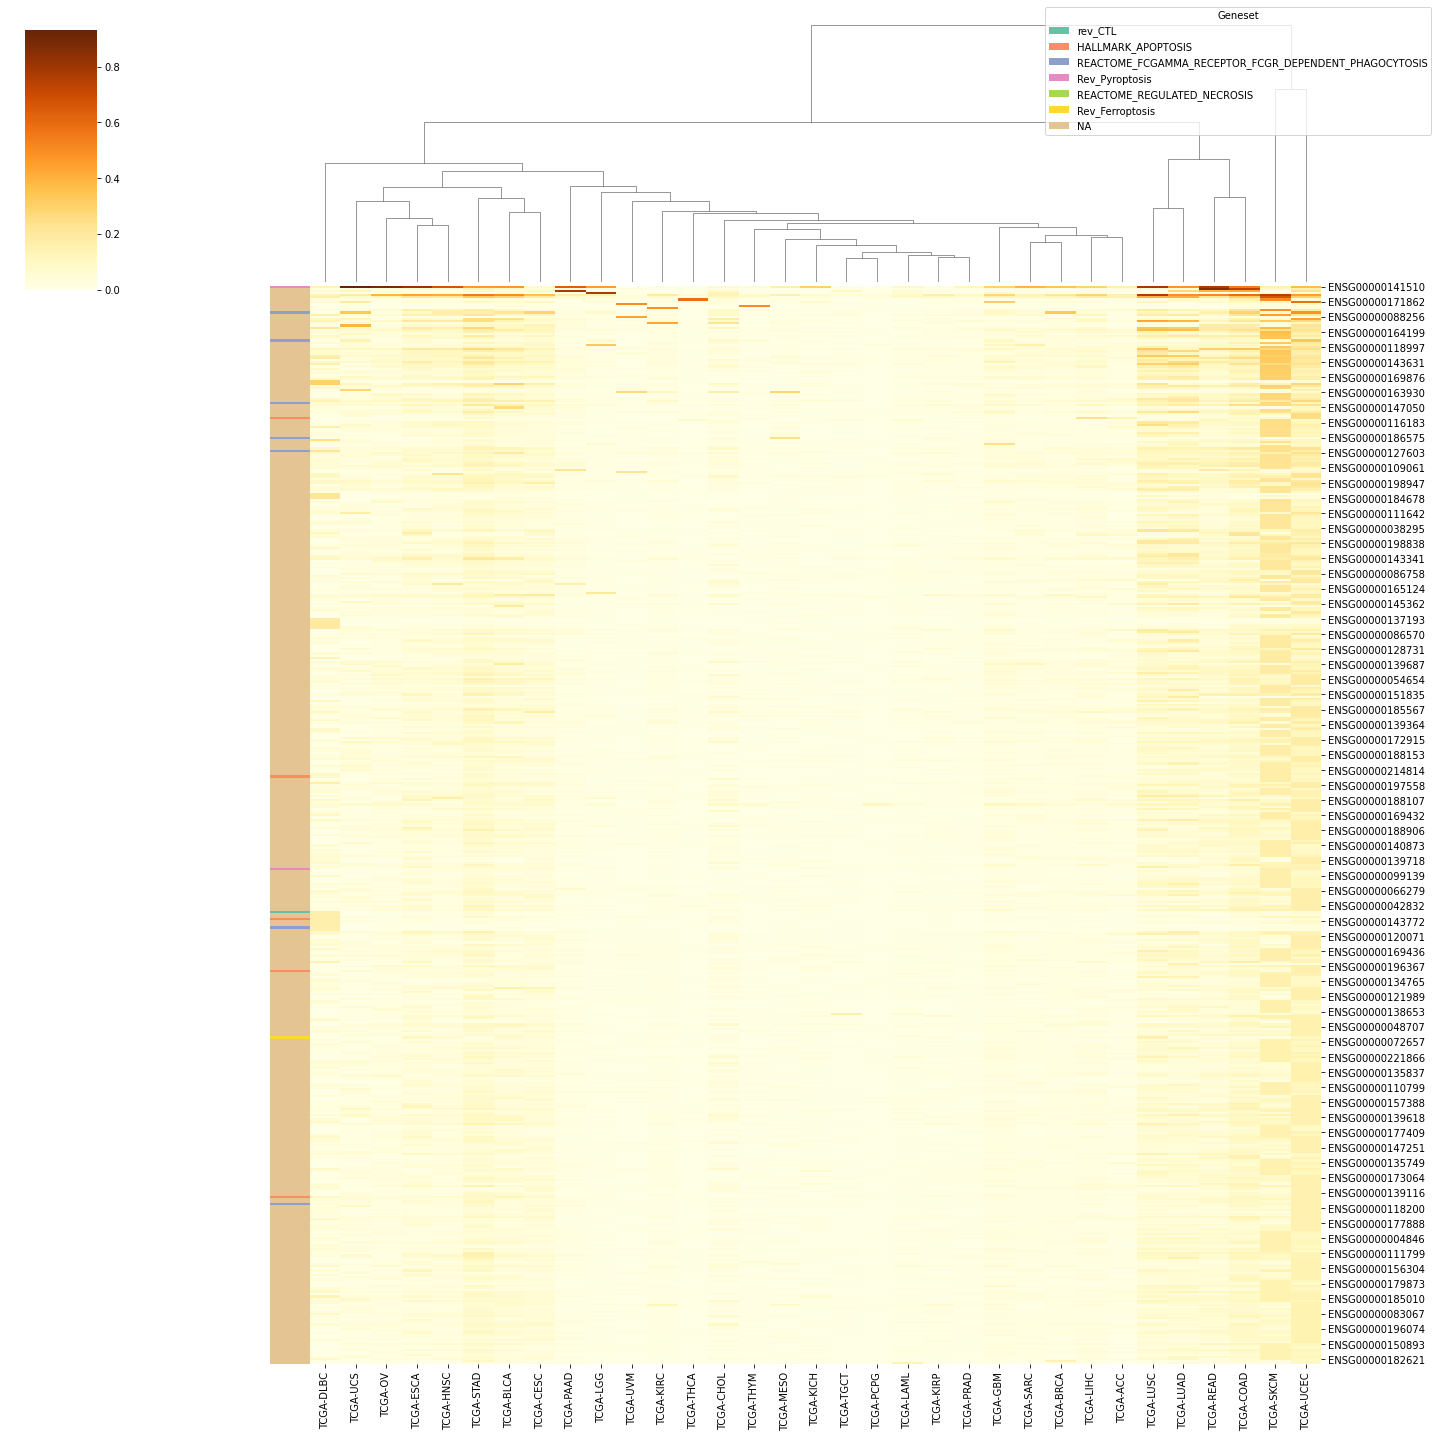

In [22]:
genesetlabs=list(ensgeneset.keys())+["NA"]
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index:
    for gs in ensgeneset.keys():
        gslab="NA"
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test[:500].index.map(gcmap)
sns.clustermap(test[:500],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr")
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

In [19]:
allcorelist = [item for sublist in ensgeneset.values() for item in sublist]
allcorelist = list(set(allcorelist))

In [20]:
inv_gsgenemap = {v: k for k, v in gsgenemap.items()}

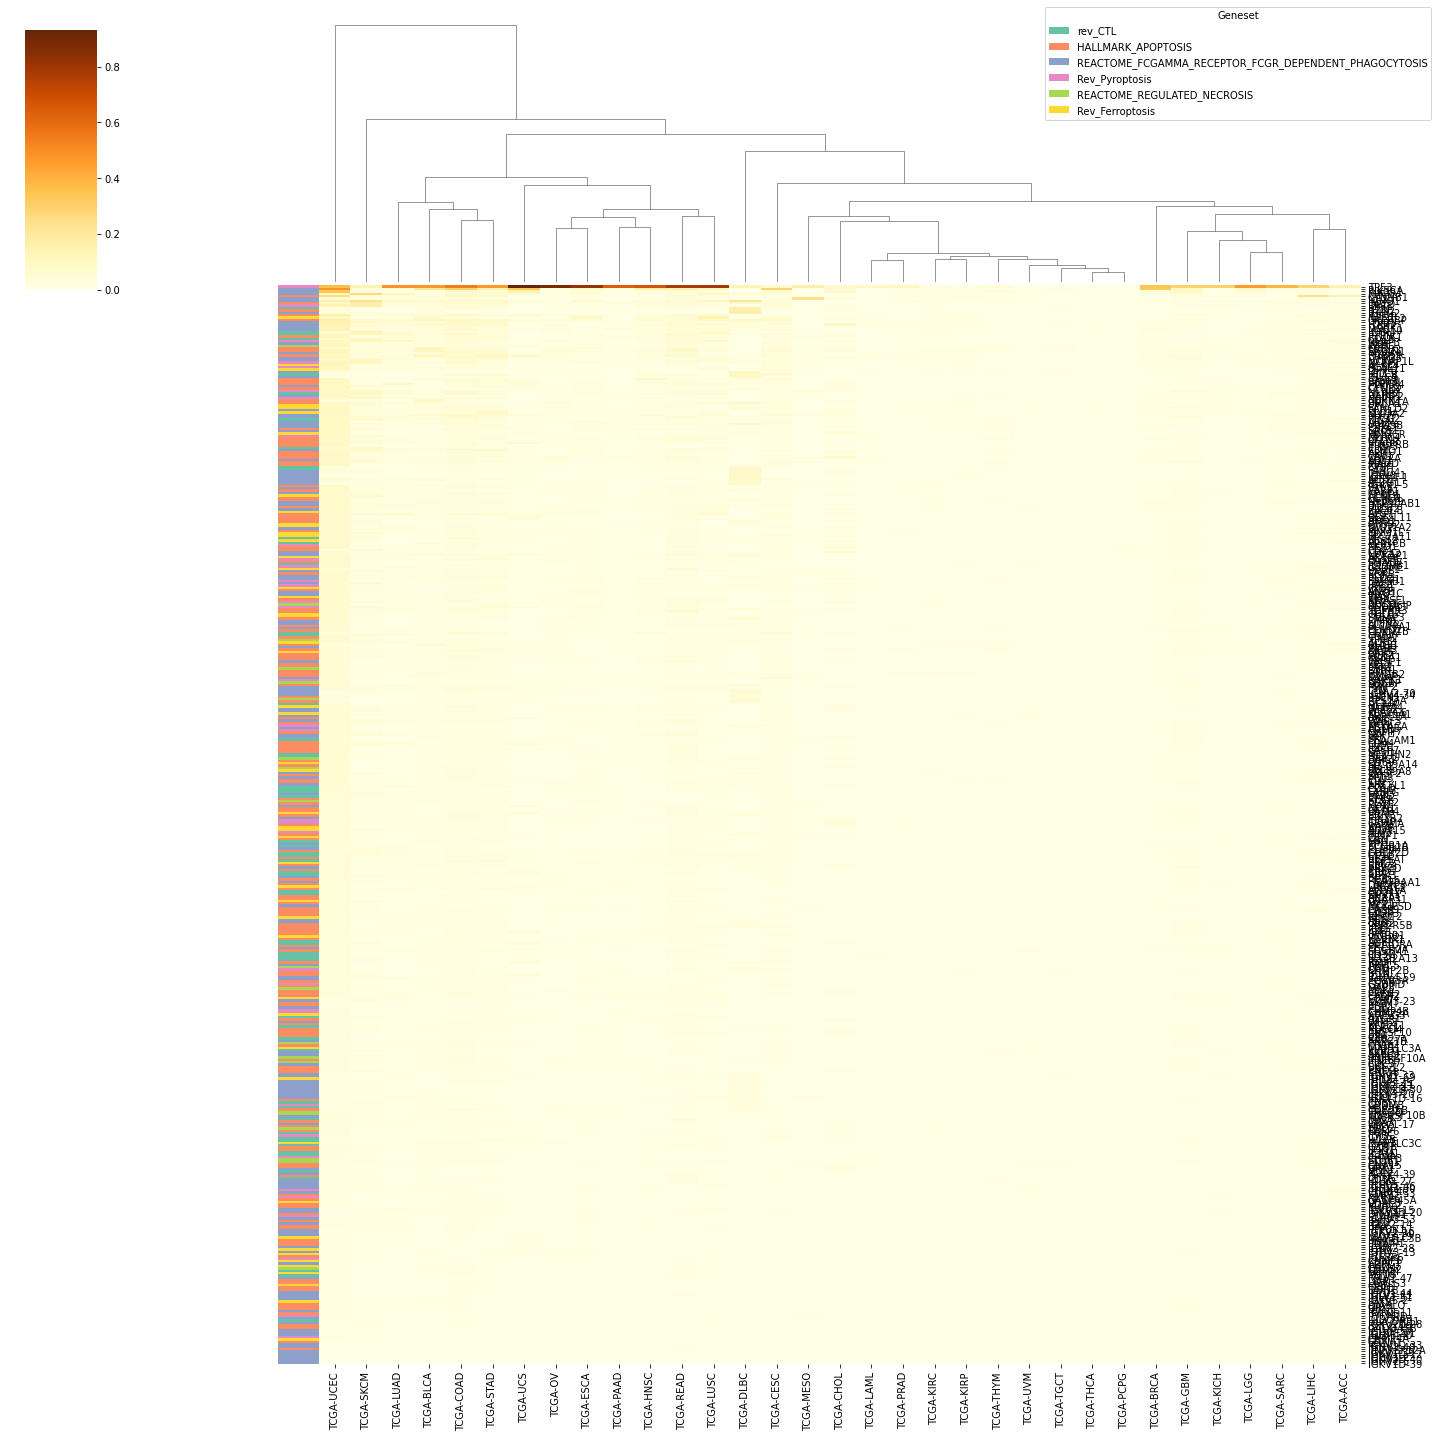

In [25]:
genesetlabs=list(ensgeneset.keys())
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index:
    for gs in genesetlabs:
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test.loc[test.index.intersection(allcorelist)].index.map(gcmap)
sns.clustermap(test.loc[test.index.intersection(allcorelist)],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr",yticklabels=[inv_gsgenemap[x] for x in test.index.intersection(allcorelist)])
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

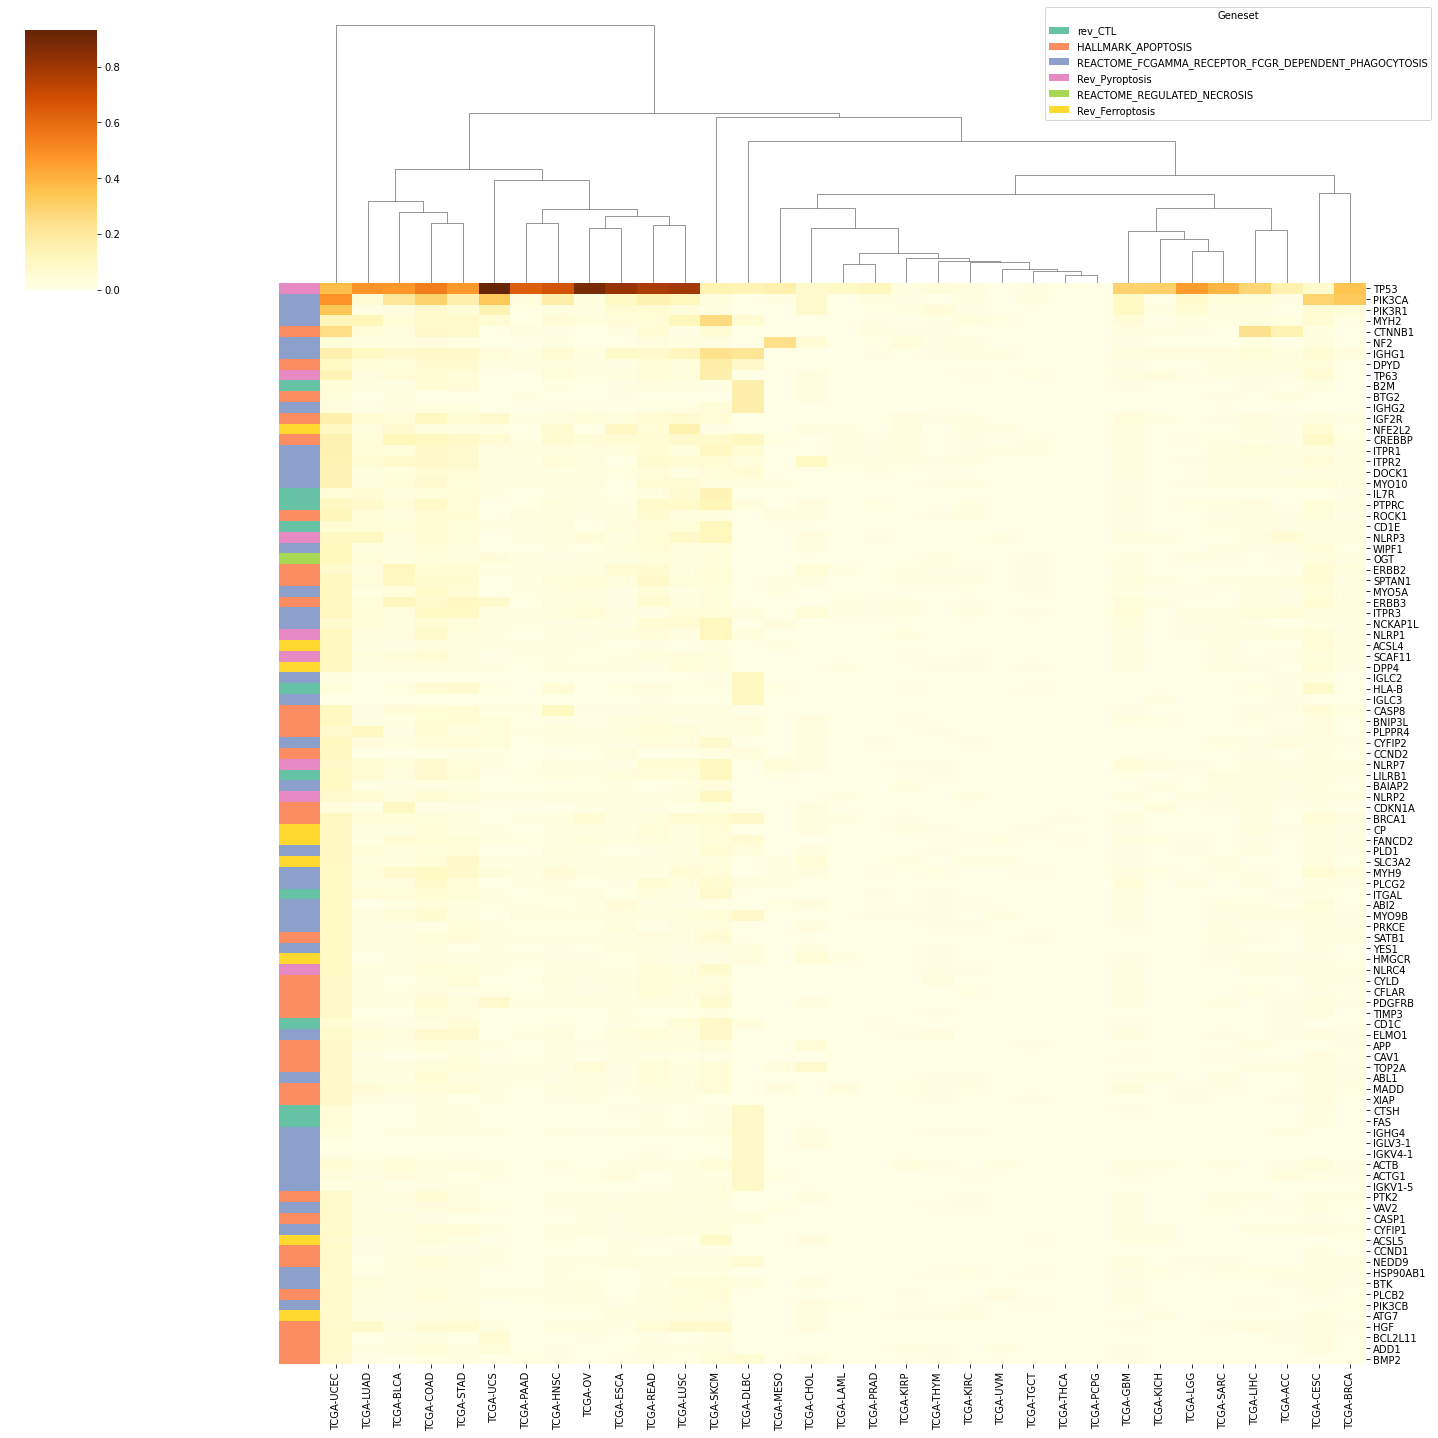

In [27]:
genesetlabs=list(ensgeneset.keys())
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index:
    for gs in genesetlabs:
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test.loc[test.index.intersection(allcorelist)][:100].index.map(gcmap)
sns.clustermap(test.loc[test.index.intersection(allcorelist)][:100],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr",yticklabels=[inv_gsgenemap[x] for x in test.index.intersection(allcorelist)[:100]])
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

In [21]:
cndmatrixlist=[]
cngmatrixlist=[]
for filename in os.listdir("cnv_cancer/"):
    if filename.endswith(".tsv"):
        temp=pd.read_csv("cnv_cancer/"+filename,sep="\t",index_col=0)
        if len(temp.columns)==0:
            continue
        temp[filename[:-11]]=temp.gt(0).sum(axis=1)/len(temp.columns)
        cngmatrixlist.append(temp.filter([filename[:-11]]))
        temp[filename[:-11]]=temp.lt(0).sum(axis=1)/len(temp.columns)
        cndmatrixlist.append(temp.filter([filename[:-11]]))

In [22]:
ngs_cmatrix=pd.concat(cndmatrixlist, axis=1)
test=ngs_cmatrix.loc[ngs_cmatrix.max(axis=1).sort_values(ascending = False).index,ngs_cmatrix.max().sort_values(ascending = False).index]

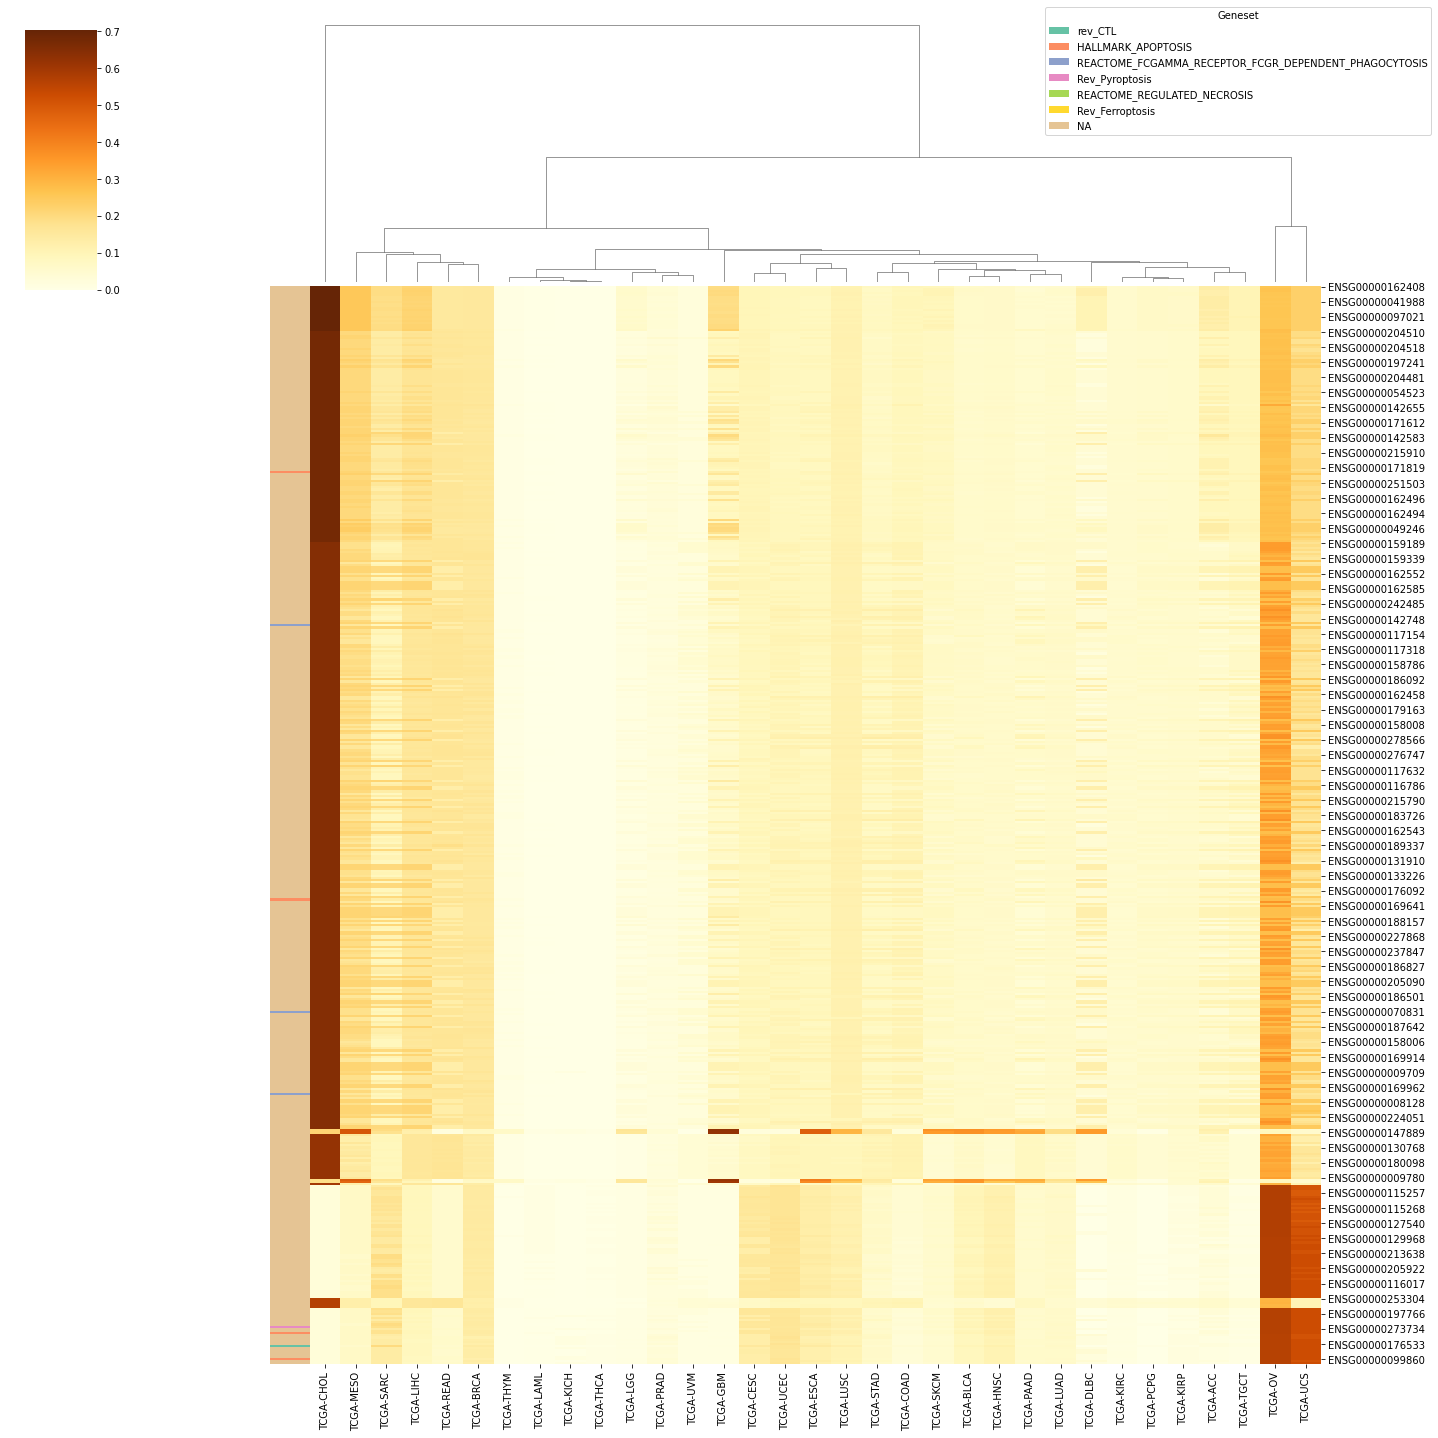

In [29]:
genesetlabs=list(ensgeneset.keys())+["NA"]
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index:
    for gs in ensgeneset.keys():
        gslab="NA"
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test[:500].index.map(gcmap)
sns.clustermap(test[:500],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr")
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

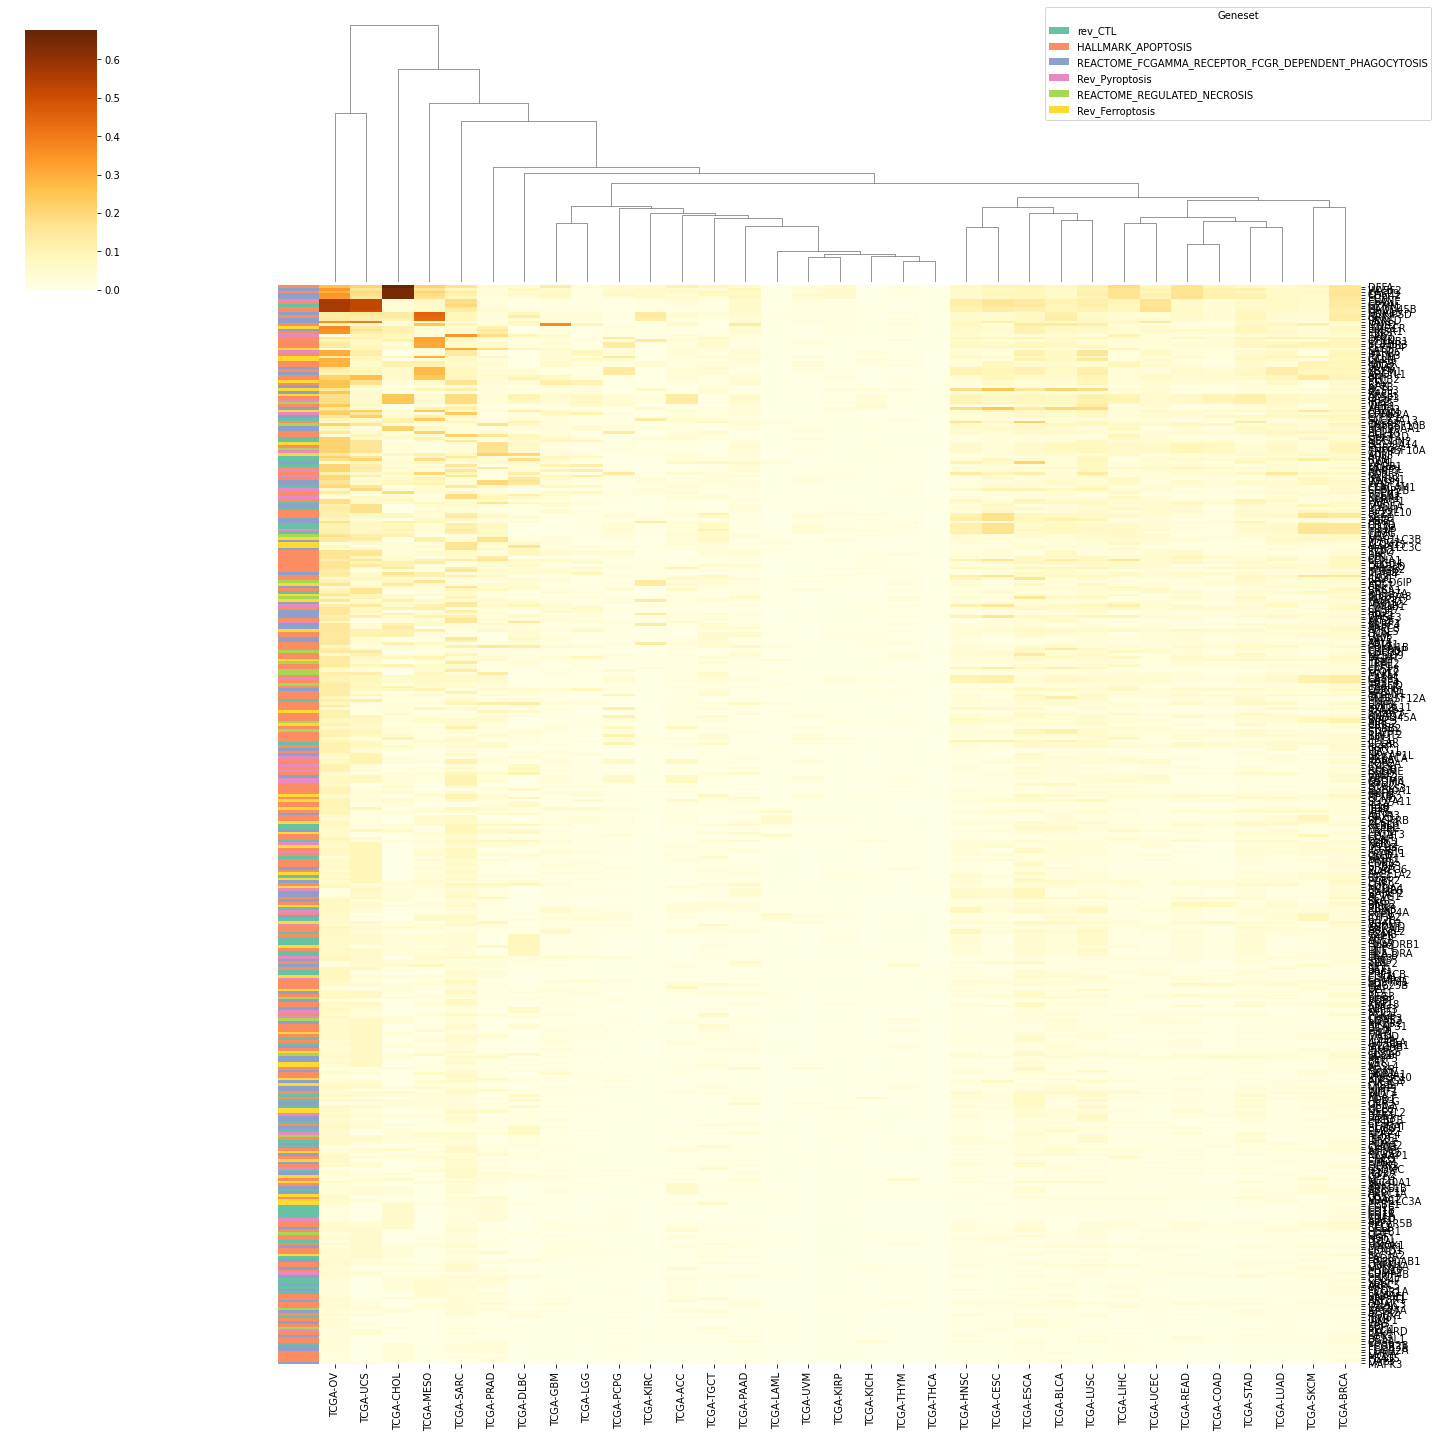

In [30]:
genesetlabs=list(ensgeneset.keys())
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index.intersection(allcorelist):
    for gs in genesetlabs:
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test.loc[test.index.intersection(allcorelist)].index.map(gcmap)
sns.clustermap(test.loc[test.index.intersection(allcorelist)],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr",yticklabels=[inv_gsgenemap[x] for x in test.index.intersection(allcorelist)])
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

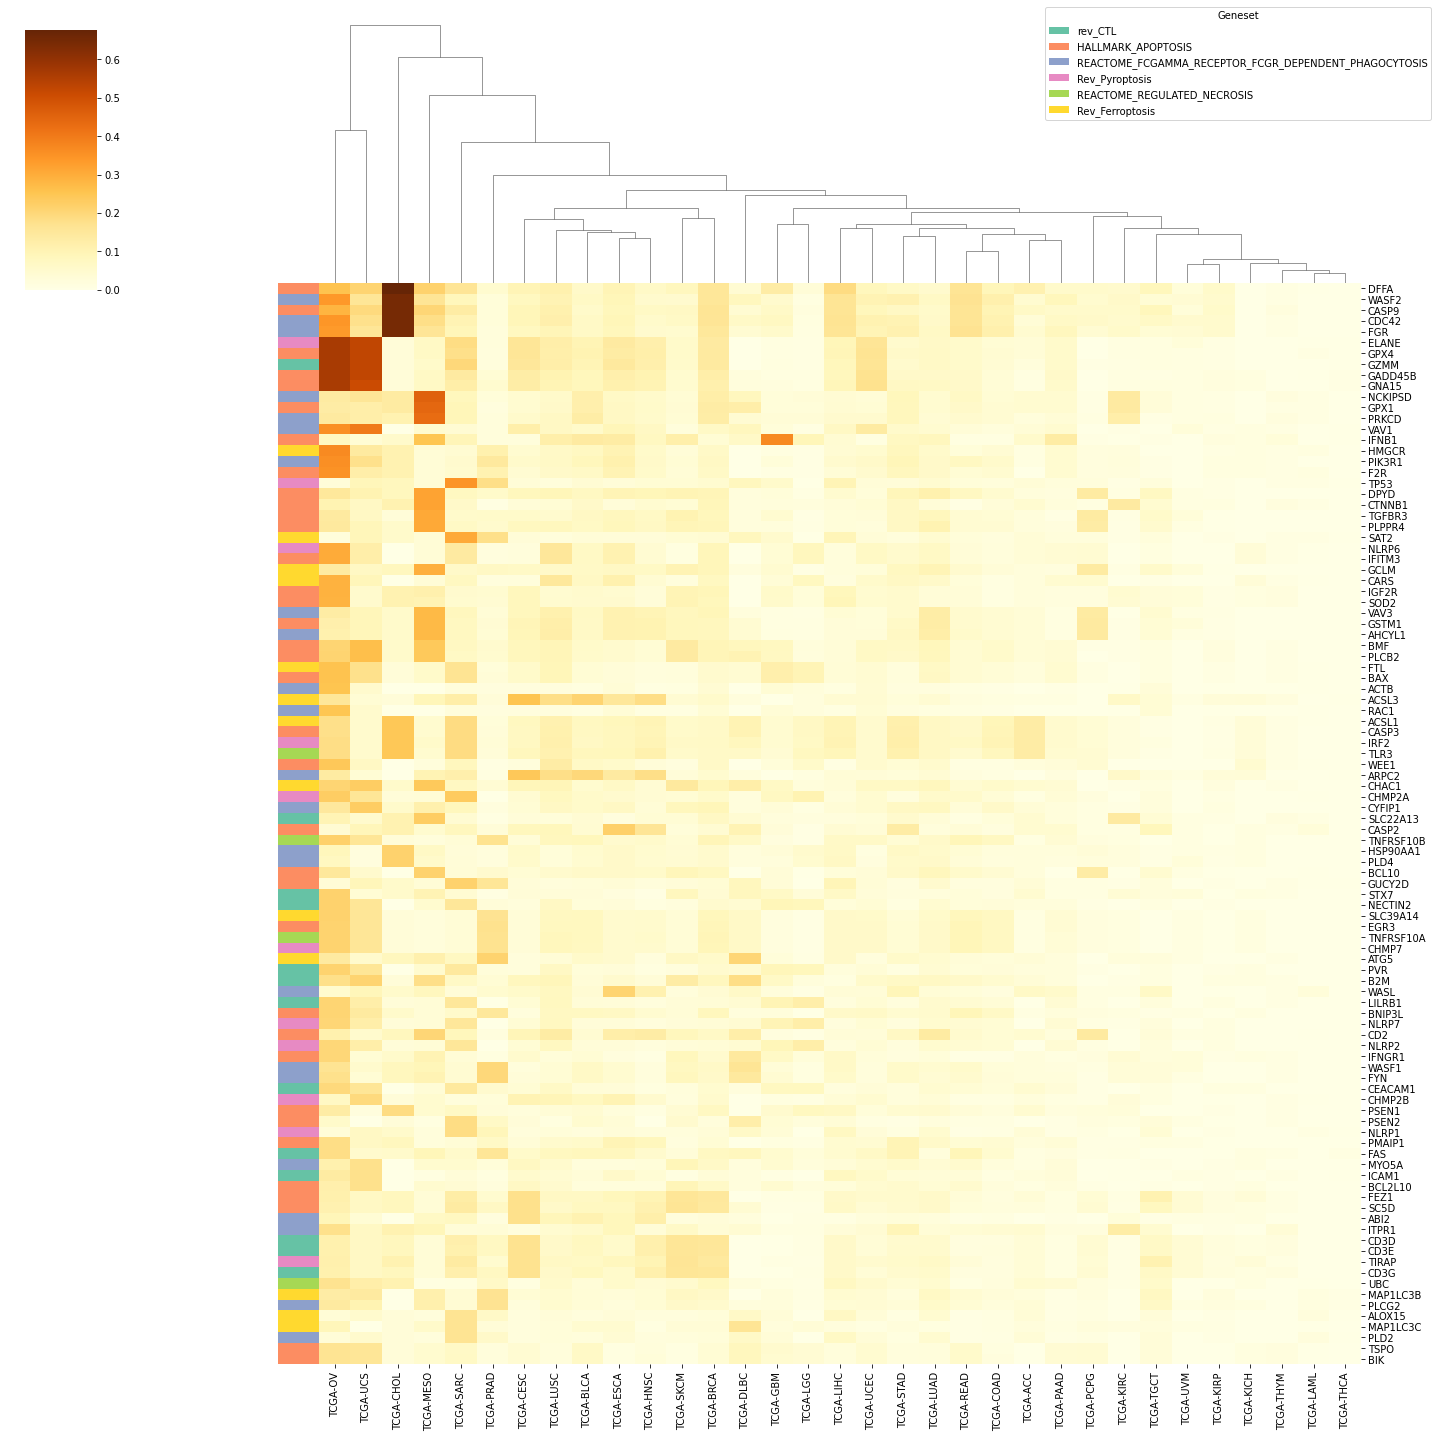

In [31]:
genesetlabs=list(ensgeneset.keys())
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in test.index:
    for gs in genesetlabs:
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = test.loc[test.index.intersection(allcorelist)][:100].index.map(gcmap)
sns.clustermap(test.loc[test.index.intersection(allcorelist)][:100],figsize=(20,20),row_colors=rc,row_cluster=False,cmap="YlOrBr",yticklabels=[inv_gsgenemap[x] for x in test.index.intersection(allcorelist)[:100]])
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

In [17]:
from scipy.stats import ranksums
import random

In [15]:
rsdict={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict[filename[:-11]]={}
        for ens in ensgeneset:
            rsdict[filename[:-11]][ens]=ranksums(tot.loc[tot.index.intersection(ensgeneset[ens]),filename[:-11]].values,tot[filename[:-11]].values,alternative='greater')[1]

In [41]:
countens={}
for gs in ensgeneset:
    for g in ensgeneset[gs]:
        if g in countens:
            countens[g]+=1
        else:
            countens[g]=1

In [16]:
rsdict

{'TCGA-PAAD': {'rev_CTL': 0.9999943434655262,
  'HALLMARK_APOPTOSIS': 0.9964522920130353,
  'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS': 0.00031990023326503215,
  'Rev_Pyroptosis': 0.9098933570529453,
  'REACTOME_REGULATED_NECROSIS': 0.9569921472105744,
  'Rev_Ferroptosis': 0.9866064024402343},
 'TCGA-SKCM': {'rev_CTL': 0.024328542043232308,
  'HALLMARK_APOPTOSIS': 0.006082156204954951,
  'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS': 0.8786596289602286,
  'Rev_Pyroptosis': 0.0227834146797445,
  'REACTOME_REGULATED_NECROSIS': 0.38165287457288843,
  'Rev_Ferroptosis': 0.1639148206212172},
 'TCGA-READ': {'rev_CTL': 0.9996592030450225,
  'HALLMARK_APOPTOSIS': 0.9994700240720359,
  'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS': 1.5342430375155881e-06,
  'Rev_Pyroptosis': 0.9462106011739416,
  'REACTOME_REGULATED_NECROSIS': 0.9814875481413046,
  'Rev_Ferroptosis': 0.9787395065671648},
 'TCGA-TGCT': {'rev_CTL': 0.999640980126216,
  'HALLMARK_APOPTOSIS': 0.9486

In [133]:
rep_genes=pd.Series(countens)[pd.Series(countens)>2].index.tolist()
rsdict_2={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict_2[filename[:-11]]={}
        rsdict_2[filename[:-11]]=ranksums(tot.loc[tot.index.intersection(rep_genes),filename[:-11]].values,tot.loc[tot.index.intersection(allcorelist),filename[:-11]].values,alternative='greater')[1]

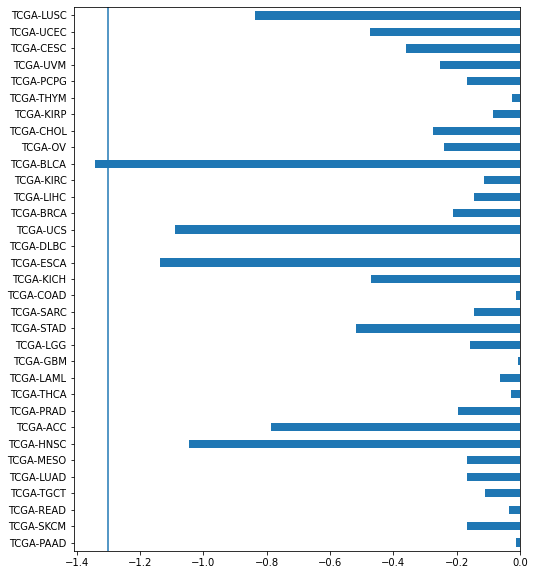

In [132]:
plt.rcParams["figure.figsize"] = (8,10)
pd.Series(rsdict_2).transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

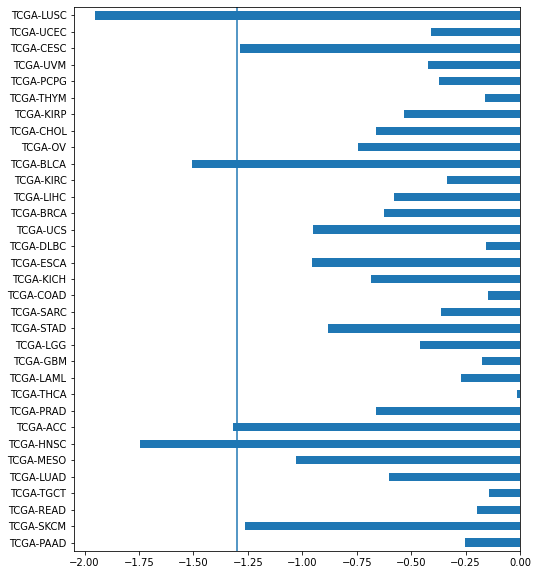

In [134]:
plt.rcParams["figure.figsize"] = (8,10)
pd.Series(rsdict_2).transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

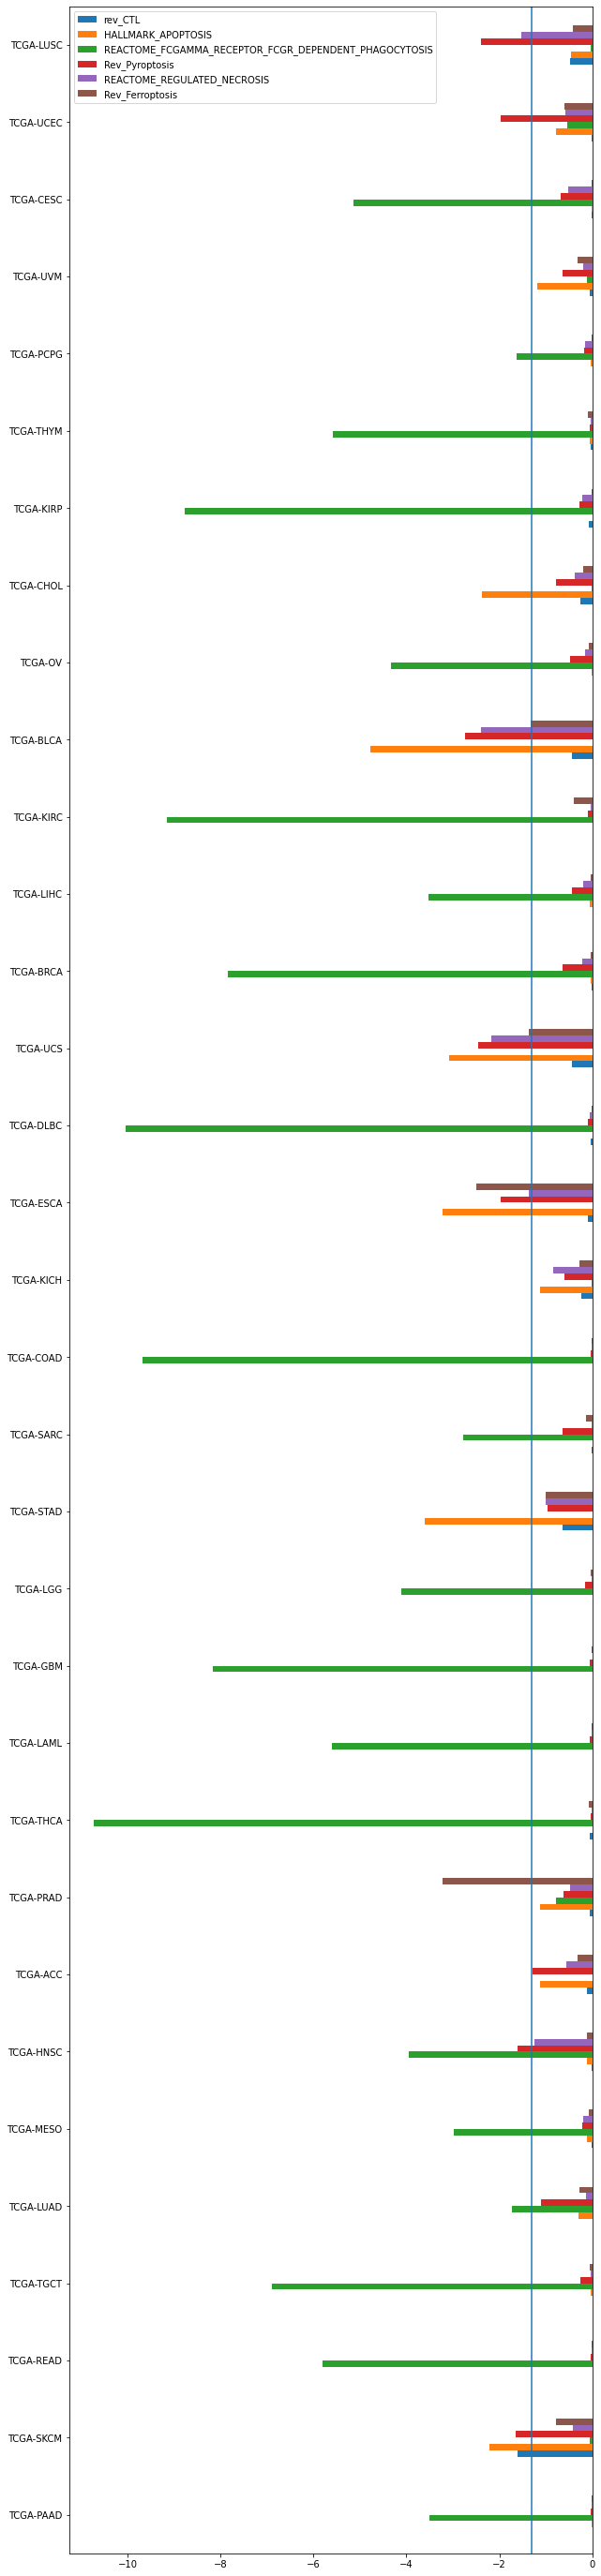

In [17]:
plt.rcParams["figure.figsize"] = (10,50)
mut_ranksums=pd.DataFrame.from_dict(rsdict,orient='index')
mut_ranksums.transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

In [31]:
testmutrs[~testmutrs['index'].isin(['TCGA-PAAD','TCGA-LUAD','TCGA-LUSC','TCGA-COAD','TCGA-BRCA','TCGA-LIHC','TCGA-UCEC','TCGA-KIRC'])].index

Int64Index([ 1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18, 19,
            23, 24, 25, 26, 27, 28, 29, 30],
           dtype='int64')

In [18]:
canordlist=['TCGA-PAAD','TCGA-LUAD','TCGA-LUSC','TCGA-COAD','TCGA-BRCA','TCGA-LIHC','TCGA-UCEC','TCGA-KIRC']

In [66]:
plt.rcParams["figure.figsize"] = (10,10)
sns.set_style("ticks",{'axes.grid' : True})
testmutrs=mut_ranksums.copy()
testmutrs.drop(testmutrs.loc[~testmutrs.index.isin(['TCGA-PAAD','TCGA-LUAD','TCGA-LUSC','TCGA-COAD','TCGA-BRCA','TCGA-LIHC','TCGA-UCEC','TCGA-KIRC'])].index,inplace=True)
testmutrs=testmutrs.transform(np.log10)
sns.barplot(y='level_0',x=0,hue='level_1',data=testmutrs.stack().reset_index(),order=)
plt.axvline(x=-1.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

SyntaxError: invalid syntax (3097363083.py, line 6)

In [18]:
cosmic_cgc=pd.read_csv("genesets/Census_allThu Nov 18 15_47_47 2021.tsv",sep='\t')

In [49]:
for r in genesetdict

{'rev_CTL': ['AGER',
  'AZGP1',
  'B2M',
  'CD1A',
  'CD1B',
  'CD1C',
  'CD1D',
  'CD1E',
  'CEACAM1',
  'CTSC',
  'CTSH',
  'CYRIB',
  'EMP2',
  'FADD',
  'FCGR2B',
  'GZMM',
  'HLA-A',
  'HLA-B',
  'HLA-DRA',
  'HLA-DRB1',
  'HLA-E',
  'HLA-F',
  'HLA-G',
  'HLA-H',
  'HPRT1',
  'IL12A',
  'IL12B',
  'IL12RB1',
  'IL23A',
  'IL23R',
  'IL7R',
  'KLRC1',
  'KLRD1',
  'LILRB1',
  'MICA',
  'MR1',
  'NECTIN2',
  'PPP3CB',
  'PRF1',
  'PTPRC',
  'PVR',
  'RAB27A',
  'RIPK3',
  'SLC22A13',
  'STX7',
  'XCL1',
  'CD247',
  'CD3D',
  'CD3E',
  'CD3G',
  'FAS',
  'FASLG',
  'GZMB',
  'ICAM1',
  'ITGAL',
  'ITGB2'],
 'HALLMARK_APOPTOSIS': ['ADD1',
  'AIFM3',
  'ANKH',
  'ANXA1',
  'APP',
  'ATF3',
  'AVPR1A',
  'BAX',
  'BCAP31',
  'BCL10',
  'BCL2L1',
  'BCL2L10',
  'BCL2L11',
  'BCL2L2',
  'BGN',
  'BID',
  'BIK',
  'BIRC3',
  'BMF',
  'BMP2',
  'BNIP3L',
  'BRCA1',
  'BTG2',
  'BTG3',
  'CASP1',
  'CASP2',
  'CASP3',
  'CASP4',
  'CASP6',
  'CASP7',
  'CASP8',
  'CASP9',
  'CAV1',
  'CCNA

In [124]:
import gseapy as gp
names = gp.get_library_name()

In [125]:
names

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_CellLines_2019',
 'Descartes_Cell_Types_and_Tissue_2021',
 'DisGeNET',
 'Disease_Perturbations_from_GEO_down',
 'Disease_Perturbati

In [140]:
enr1 = gp.enrichr(gene_list=genesetdict["REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS"],
                 gene_sets=['GO_Molecular_Function_2021','GO_Biological_Process_2021','KEGG_2021_Human','WikiPathways_2019_Human','DisGeNET'],
                 organism='Human', # don't forget to set organism to the one you desired! e.g. Yeast
                 description='Reactome FCGR',
                 outdir='test/enrichr_phago',
                 # no_plot=True,
                 cutoff=0.05 # test dataset, use lower value from range(0,1)
                )

2021-11-12 09:27:07,210 Error fetching enrichment results: GO_Molecular_Function_2021
2021-11-12 09:27:08,984 Error fetching enrichment results: GO_Biological_Process_2021
2021-11-12 09:27:10,684 Error fetching enrichment results: KEGG_2021_Human
2021-11-12 09:27:13,280 Error fetching enrichment results: WikiPathways_2019_Human
2021-11-12 09:27:14,888 Error fetching enrichment results: DisGeNET


In [141]:
matlist=[]
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        matlist.append(tot.loc[tot.index.intersection(allcorelist),[filename[:-11]]])

In [142]:
totmatrix=pd.concat(matlist, axis=1)

/Users/jayashankara2/Desktop/Projectideas/celldeathmechas/celldeath/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


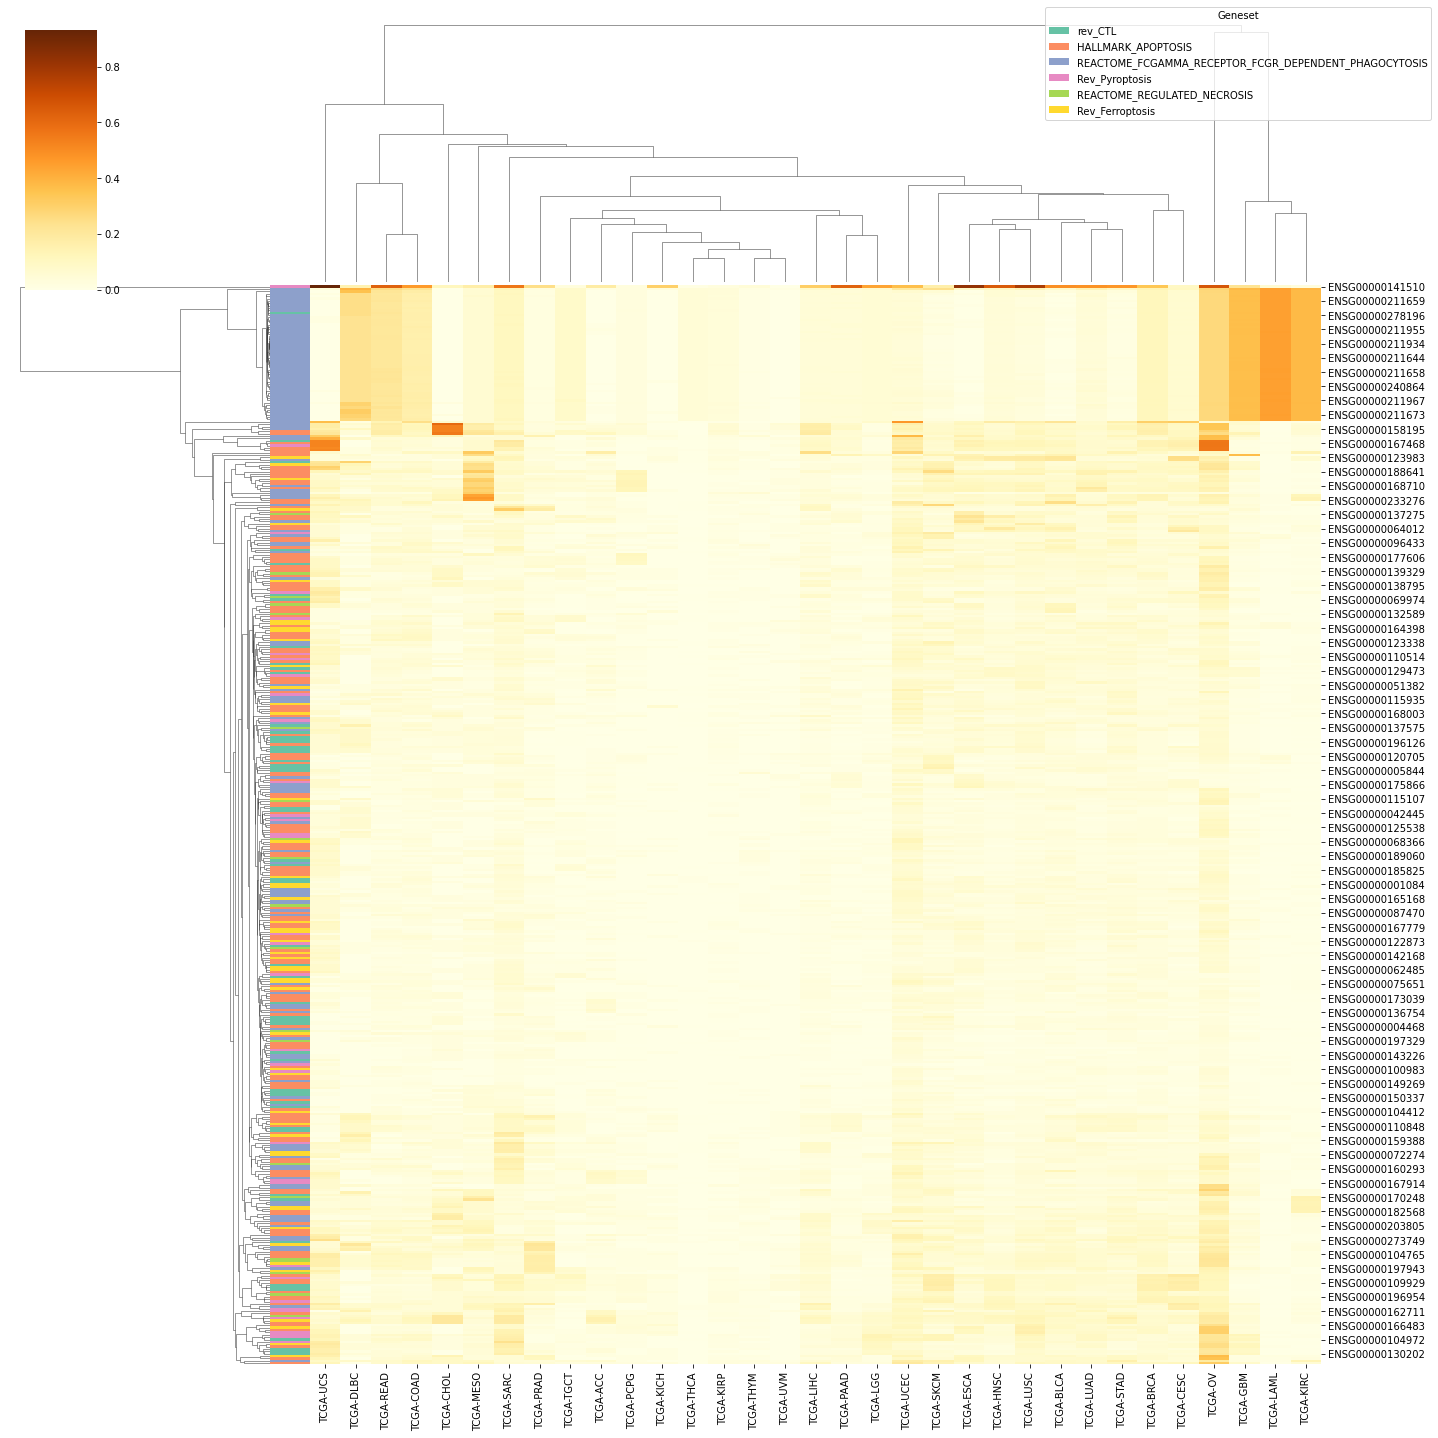

In [144]:
genesetlabs=list(ensgeneset.keys())
clrs2=sns.color_palette("Set2", len(genesetlabs))
glut=dict(zip(genesetlabs, list(clrs2.as_hex())))
gcmap={}
for g in totmatrix.index:
    for gs in ensgeneset.keys():
        if g in ensgeneset[gs]:
            gslab=gs
            break
    gcmap[g]=glut[gslab]
rc = totmatrix.index.map(gcmap)
sns.clustermap(totmatrix,figsize=(20,20),row_colors=rc,cmap="YlOrBr")
handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(handles2,glut, title='Geneset',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

In [145]:
genesetdict["REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS"]

['ABI1',
 'ABI2',
 'ABL1',
 'ACTB',
 'ACTG1',
 'ACTR2',
 'ACTR3',
 'AHCYL1',
 'ARPC1A',
 'ARPC1B',
 'ARPC2',
 'ARPC3',
 'ARPC4',
 'ARPC5',
 'BAIAP2',
 'BRK1',
 'BTK',
 'CD247',
 'CD3G',
 'CDC42',
 'CFL1',
 'CRK',
 'CYFIP1',
 'CYFIP2',
 'DOCK1',
 'ELMO1',
 'ELMO2',
 'FCGR1A',
 'FCGR2A',
 'FCGR3A',
 'FGR',
 'FYN',
 'GRB2',
 'HCK',
 'HSP90AA1',
 'HSP90AB1',
 'IGHG1',
 'IGHG2',
 'IGHG4',
 'IGHV1-2',
 'IGHV1-46',
 'IGHV1-69',
 'IGHV2-5',
 'IGHV2-70',
 'IGHV3-11',
 'IGHV3-13',
 'IGHV3-23',
 'IGHV3-30',
 'IGHV3-33',
 'IGHV3-48',
 'IGHV3-53',
 'IGHV3-7',
 'IGHV4-34',
 'IGHV4-39',
 'IGHV4-59',
 'IGKV1-12',
 'IGKV1-16',
 'IGKV1-17',
 'IGKV1-33',
 'IGKV1-39',
 'IGKV1-5',
 'IGKV1D-12',
 'IGKV1D-16',
 'IGKV1D-33',
 'IGKV1D-39',
 'IGKV2-28',
 'IGKV2-30',
 'IGKV2D-28',
 'IGKV2D-30',
 'IGKV2D-40',
 'IGKV3-11',
 'IGKV3-15',
 'IGKV3-20',
 'IGKV3D-20',
 'IGKV4-1',
 'IGKV5-2',
 'IGLC2',
 'IGLC3',
 'IGLV1-40',
 'IGLV1-44',
 'IGLV1-47',
 'IGLV1-51',
 'IGLV2-11',
 'IGLV2-14',
 'IGLV2-23',
 'IGLV2-8',
 'IGLV3

In [21]:
cosmic_cgc['Ensembl']=cosmic_cgc['Gene Symbol'].map(tcgaensdict)

In [22]:
cosmic_cgc

,Gene Symbol,Name,Entrez GeneId,Genome Location,Tier,Hallmark,Chr Band,Somatic,Germline,Tumour Types(Somatic),...,Cancer Syndrome,Tissue Type,Molecular Genetics,Role in Cancer,Mutation Types,Translocation Partner,Other Germline Mut,Other Syndrome,Synonyms,Ensembl
0,A1CF,APOBEC1 complementation factor,29974.0,10:52566322-52645435,2,NaN,11.23,yes,NaN,melanoma,...,NaN,E,NaN,oncogene,Mis,NaN,NaN,NaN,"29974,A1CF,ACF,ACF64,ACF65,APOBEC1CF,ASP,ENSG0...",ENSG00000148584
1,ABI1,abl-interactor 1,10006.0,10:27035522-27149864,1,Yes,12.10,yes,NaN,AML,...,NaN,L,Dom,"TSG, fusion",T,KMT2A,NaN,NaN,"10006,ABI-1,ABI1,E3B1,ENSG00000136754.12,Q8IZP...",ENSG00000136754
2,ABL1,v-abl Abelson murine leukemia viral oncogene h...,25.0,9:133589333-133761070,1,Yes,34.12,yes,NaN,"CML, ALL, T-ALL",...,NaN,L,Dom,"oncogene, fusion","T, Mis","BCR, ETV6, NUP214",NaN,NaN,"25,ABL,ABL1,ENSG00000097007.13,JTK7,P00519,c-A...",ENSG00000097007
3,ABL2,"c-abl oncogene 2, non-receptor tyrosine kinase",27.0,1:179068462-179198736,1,NaN,25.20,yes,NaN,AML,...,NaN,L,Dom,"oncogene, fusion",T,ETV6,NaN,NaN,"27,ABL2,ABLL,ARG,ENSG00000143322.15,P42684",ENSG00000143322
4,ACKR3,atypical chemokine receptor 3,57007.0,2:237478284-237491001,1,Yes,37.30,yes,NaN,lipoma,...,NaN,M,Dom,"oncogene, fusion",T,HMGA2,NaN,NaN,"57007,ACKR3,CMKOR1,CXCR7,ENSG00000144476.5,GPR...",ENSG00000144476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,ZNF429,zinc finger protein 429,353088.0,19:21688366-21720880,2,NaN,12.00,yes,NaN,GBM,...,NaN,O,NaN,NaN,Mis,NaN,NaN,NaN,"353088,ENSG00000197013.5,Q86V71,ZNF429",ENSG00000197013
719,ZNF479,zinc finger protein 479,90827.0,7:57187321-57207571,2,NaN,11.20,yes,NaN,"lung cancer, bladder carcinoma, prostate carci...",...,NaN,E,NaN,NaN,Mis,NaN,NaN,NaN,"90827,ENSG00000185177.8,KR19,Q96JC4,ZNF479",ENSG00000185177
720,ZNF521,zinc finger protein 521,25925.0,18:22641890-22932116,1,NaN,11.20,yes,NaN,ALL,...,NaN,L,Dom,"oncogene, fusion",T,PAX5,NaN,NaN,"25925,EHZF,ENSG00000198795.6,Evi3,Q96K83,ZNF521",ENSG00000198795
721,ZNRF3,zinc and ring finger 3,84133.0,22:29279580-29453475,2,NaN,12.10,yes,NaN,"colorectal cancer, adrenocortical carcinoma, g...",...,NaN,E,NaN,TSG,"N, F, Mis",NaN,NaN,NaN,"84133,BK747E2.3,ENSG00000183579.11,FLJ22057,KI...",ENSG00000183579


In [35]:
cgcoverlap={}
for gs in ensgeneset:
    cgcoverlap[gs]=[]
    for g in ensgeneset[gs]:
        if g in cosmic_cgc['Ensembl'].values.tolist():
            cgcoverlap[gs].append(g)

In [36]:
ensgeneset

{'rev_CTL': ['ENSG00000204305',
  'ENSG00000160862',
  'ENSG00000166710',
  'ENSG00000158477',
  'ENSG00000158485',
  'ENSG00000158481',
  'ENSG00000158473',
  'ENSG00000158488',
  'ENSG00000079385',
  'ENSG00000109861',
  'ENSG00000103811',
  'ENSG00000153310',
  'ENSG00000213853',
  'ENSG00000168040',
  'ENSG00000072694',
  'ENSG00000197540',
  'ENSG00000206503',
  'ENSG00000234745',
  'ENSG00000204287',
  'ENSG00000196126',
  'ENSG00000204592',
  'ENSG00000204642',
  'ENSG00000204632',
  'ENSG00000206341',
  'ENSG00000165704',
  'ENSG00000168811',
  'ENSG00000113302',
  'ENSG00000096996',
  'ENSG00000110944',
  'ENSG00000162594',
  'ENSG00000168685',
  'ENSG00000134545',
  'ENSG00000134539',
  'ENSG00000104972',
  'ENSG00000204520',
  'ENSG00000153029',
  'ENSG00000130202',
  'ENSG00000107758',
  'ENSG00000180644',
  'ENSG00000081237',
  'ENSG00000073008',
  'ENSG00000069974',
  'ENSG00000129465',
  'ENSG00000172940',
  'ENSG00000079950',
  'ENSG00000143184',
  'ENSG00000198821',
  

In [61]:
cgcoverlap
countcgcoverlap={x:len(cgcoverlap[x]) for x in cgcoverlap}

<AxesSubplot:>

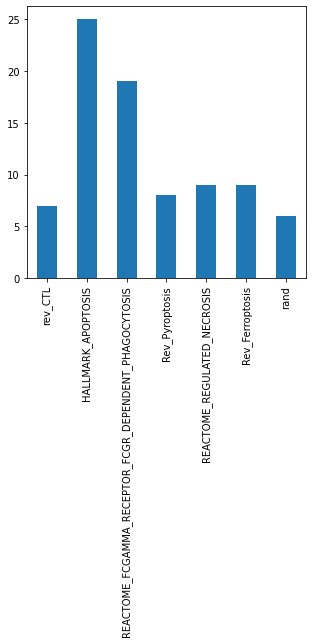

In [62]:
plt.rcParams["figure.figsize"] = (5,5)
pd.Series(countcgcoverlap).plot(kind='bar')

In [64]:
frac=723/20000
expcount={}
for gs in ensgeneset:
    expcount[gs]=len(ensgeneset[gs])*frac
expcount['rand']=200*frac

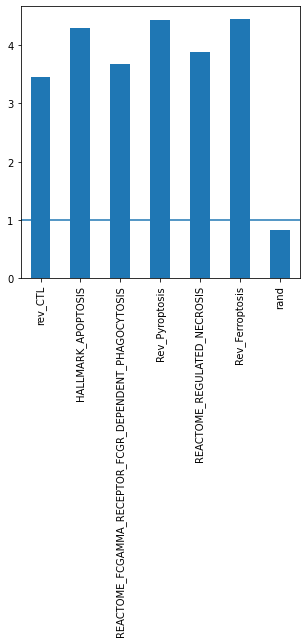

In [65]:
(pd.Series(countcgcoverlap)/pd.Series(expcount)).plot(kind='bar')
plt.axhline(1)

In [59]:
rand=random.sample(cngenelist,200)

In [60]:
cgcoverlap['rand']=[]
for g in rand:
    if g in cosmic_cgc['Ensembl'].values.tolist():
        cgcoverlap['rand'].append(g)

In [76]:
rep_genes=cosmic_cgc['Ensembl'].values.tolist()
rsdict_3={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict_3[filename[:-11]]={}
        rsdict_3[filename[:-11]]=ranksums(tot.loc[tot.index.intersection(rep_genes),filename[:-11]].values,tot.loc[tot.index.intersection(allcorelist),filename[:-11]].values,alternative='greater')[1]

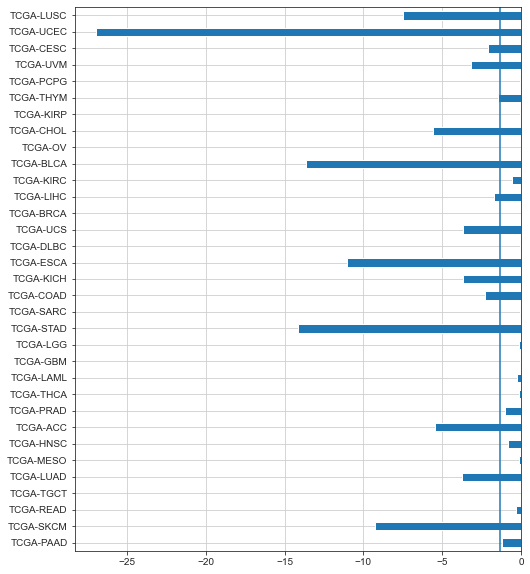

In [77]:
plt.rcParams["figure.figsize"] = (8,10)
pd.Series(rsdict_3).transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

In [78]:
rep_genes=cosmic_cgc['Ensembl'].values.tolist()
rsdict_4={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict_4[filename[:-11]]={}
        rsdict_4[filename[:-11]]=ranksums(tot.loc[tot.index.intersection(rep_genes),filename[:-11]].values,tot.loc[tot.index.intersection(ensgeneset['REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS']),filename[:-11]].values,alternative='greater')[1]

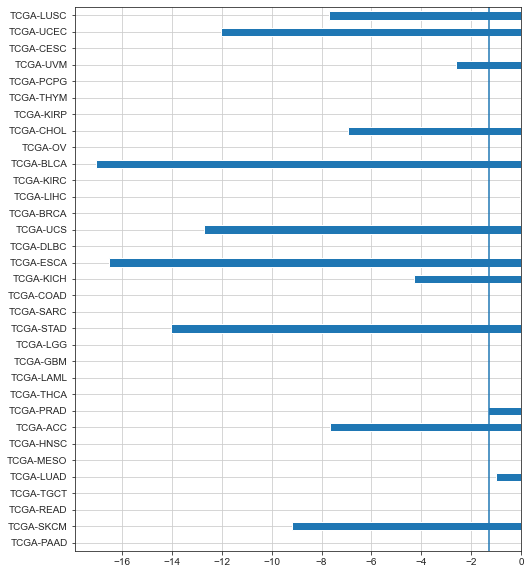

In [79]:
plt.rcParams["figure.figsize"] = (8,10)
pd.Series(rsdict_4).transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

In [80]:
rep_genes=cosmic_cgc['Ensembl'].values.tolist()
rsdict_5={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict_5[filename[:-11]]={}
        rsdict_5[filename[:-11]]=ranksums(tot.loc[tot.index.intersection(rep_genes),filename[:-11]].values,tot[filename[:-11]].values,alternative='greater')[1]

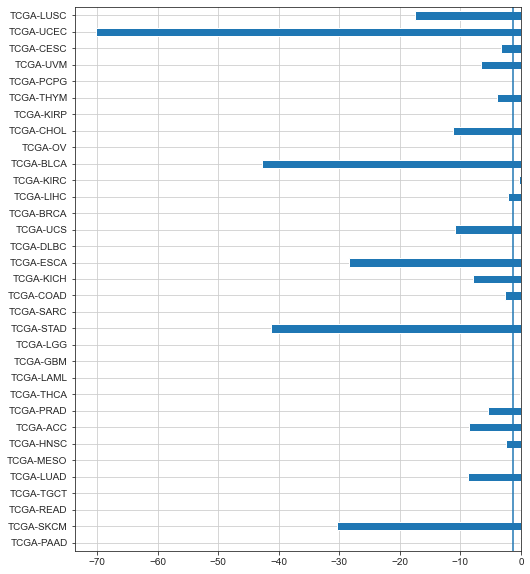

In [81]:
plt.rcParams["figure.figsize"] = (8,10)
pd.Series(rsdict_5).transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

In [82]:
rep_genes=cosmic_cgc['Ensembl'].values.tolist()
rsdict_6={}
for filename in os.listdir("snv_cancer/nonsyn/"):
    if filename.endswith(".tsv"):
        muts=pd.read_csv("snv_cancer/nonsyn/"+filename,sep="\t",index_col=0)
        cnv=pd.read_csv("cnv_cancer/"+filename[:-11]+"_cnvmat.tsv",sep="\t",index_col=0)
        cnvrev=cnv.lt(0).astype(int)
        tot=muts.add(cnvrev, fill_value=0)
        if len(muts.columns)==0 and len(cnv.columns)==0:
            continue
        tot[filename[:-11]]=np.count_nonzero(tot, axis=1)/(len(tot.columns))
        rsdict_6[filename[:-11]]={}
        for ens in ensgeneset:
            rsdict_6[filename[:-11]][ens]=ranksums(tot.loc[tot.index.intersection(ensgeneset[ens]),filename[:-11]].values,tot[filename[:-11]].values,alternative='greater')[1]
        rsdict_6[filename[:-11]]["cosmic"]=ranksums(tot.loc[tot.index.intersection(rep_genes),filename[:-11]].values,tot[filename[:-11]].values,alternative='greater')[1]

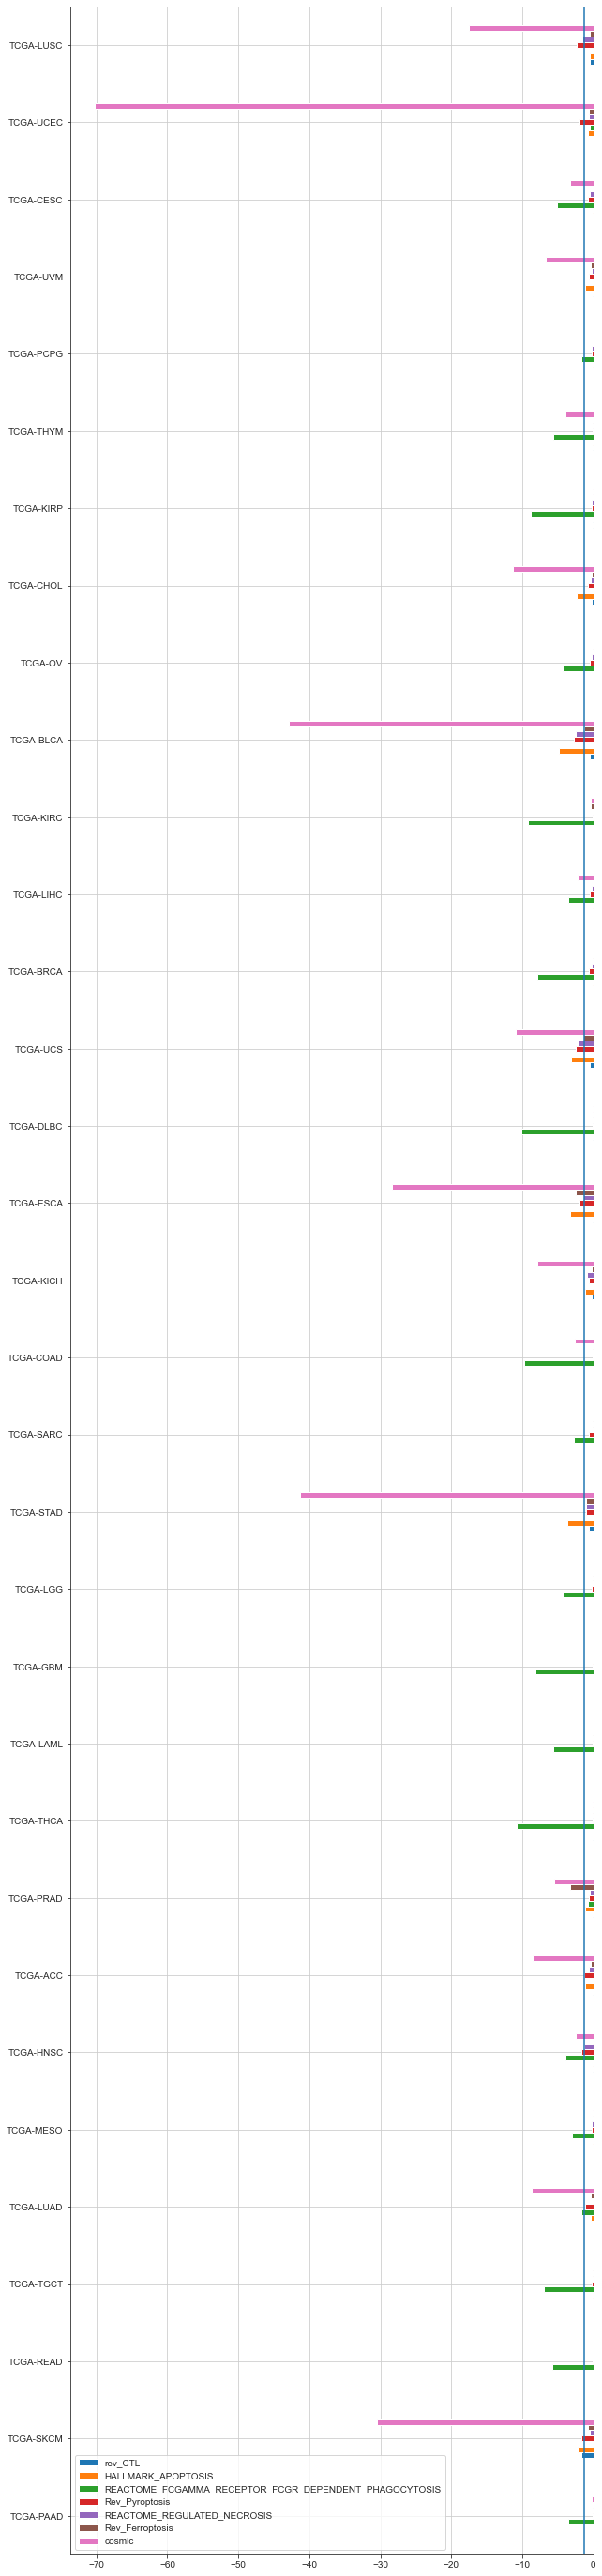

In [84]:
plt.rcParams["figure.figsize"] = (10,50)
mut_ranksums2=pd.DataFrame.from_dict(rsdict_6,orient='index')
mut_ranksums2.transform(np.log10).plot.barh()
plt.axvline(np.log10(0.05))

In [85]:
mut_ranksums2

,rev_CTL,HALLMARK_APOPTOSIS,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,Rev_Pyroptosis,REACTOME_REGULATED_NECROSIS,Rev_Ferroptosis,cosmic
TCGA-PAAD,0.999994,0.996452,3.199002e-04,0.909893,0.956992,0.986606,5.926035e-01
TCGA-SKCM,0.024329,0.006082,8.786596e-01,0.022783,0.381653,0.163915,3.831075e-31
TCGA-READ,0.999659,0.999470,1.534243e-06,0.946211,0.981488,0.978740,9.871104e-01
TCGA-TGCT,0.999641,0.948679,1.276314e-07,0.550218,0.931888,0.892150,9.999999e-01
TCGA-LUAD,0.997656,0.512740,1.896471e-02,0.079456,0.748400,0.522990,2.111342e-09
TCGA-MESO,0.980437,0.777932,1.038254e-03,0.614121,0.654518,0.828978,8.860550e-01
TCGA-HNSC,0.972505,0.785485,1.147376e-04,0.025232,0.057711,0.769590,3.646177e-03
TCGA-ACC,0.759299,0.074107,9.996171e-01,0.050975,0.280517,0.487324,2.982431e-09
TCGA-PRAD,0.866842,0.074381,1.640354e-01,0.239006,0.337930,0.000594,3.671830e-06
TCGA-THCA,0.893896,0.999943,1.869462e-11,0.949780,0.973115,0.839876,7.940627e-01


In [27]:
totmuts=test.add(ngs_cmatrix,fill_value=0)

In [28]:
totmuts

,TCGA-ACC,TCGA-BLCA,TCGA-BRCA,TCGA-CESC,TCGA-CHOL,TCGA-COAD,TCGA-DLBC,TCGA-ESCA,TCGA-GBM,TCGA-HNSC,...,TCGA-READ,TCGA-SARC,TCGA-SKCM,TCGA-STAD,TCGA-TGCT,TCGA-THCA,TCGA-THYM,TCGA-UCEC,TCGA-UCS,TCGA-UVM
ENSG00000000003,0.021978,0.014493,0.045290,0.000000,0.000000,0.017204,0.040816,0.043011,0.009868,0.011450,...,0.012048,0.083019,0.017204,0.041284,0.028571,0.003899,0.016129,0.025830,0.140351,0.000000
ENSG00000000005,0.021978,0.014493,0.045290,0.000000,0.000000,0.017204,0.040816,0.043011,0.009868,0.011450,...,0.012048,0.075472,0.017204,0.041284,0.028571,0.003899,0.016129,0.025830,0.140351,0.000000
ENSG00000000419,0.000000,0.024155,0.039855,0.046980,0.000000,0.030108,0.081633,0.043011,0.009868,0.034351,...,0.072289,0.030189,0.004301,0.022936,0.000000,0.000000,0.000000,0.022140,0.000000,0.000000
ENSG00000000457,0.065934,0.024155,0.054348,0.013423,0.000000,0.004301,0.081633,0.021505,0.016447,0.003817,...,0.000000,0.052830,0.021505,0.004587,0.000000,0.000000,0.016129,0.011070,0.000000,0.000000
ENSG00000000460,0.065934,0.024155,0.056159,0.006711,0.108108,0.004301,0.081633,0.021505,0.016447,0.003817,...,0.000000,0.052830,0.025806,0.004587,0.000000,0.000000,0.016129,0.011070,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000281873,0.065934,0.111111,0.182971,0.073826,0.108108,0.111828,0.040816,0.150538,0.059211,0.068702,...,0.060241,0.166038,0.184946,0.137615,0.042857,0.003899,0.000000,0.092251,0.456140,0.000000
ENSG00000281883,0.021978,0.338164,0.181159,0.362416,0.054054,0.047312,0.081633,0.096774,0.164474,0.202290,...,0.096386,0.354717,0.077419,0.100917,0.014286,0.015595,0.016129,0.059041,0.315789,0.000000
ENSG00000281887,0.109890,0.101449,0.123188,0.154362,0.162162,0.055914,0.204082,0.505376,0.046053,0.332061,...,0.060241,0.218868,0.068817,0.275229,0.185714,0.000000,0.016129,0.059041,0.210526,0.024691
ENSG00000281889,0.000000,0.053140,0.056159,0.006711,0.000000,0.008602,0.040816,0.032258,0.059211,0.026718,...,0.024096,0.052830,0.021505,0.045872,0.042857,0.000000,0.000000,0.033210,0.070175,0.000000


In [37]:
from scipy.stats import pearsonr

In [40]:
spdict={}
for ens in ensgeneset:
    spdict[ens]={}
    for ens2 in ensgeneset:
        spdict[ens][ens2]=pearsonr(totmuts.loc[totmuts.index.intersection(ensgeneset[ens])].mean(),totmuts.loc[totmuts.index.intersection(ensgeneset[ens2])].mean())[0]

In [42]:
pd.DataFrame(spdict)

,rev_CTL,HALLMARK_APOPTOSIS,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,Rev_Pyroptosis,REACTOME_REGULATED_NECROSIS,Rev_Ferroptosis
rev_CTL,1.000000,0.976422,0.939021,0.982749,0.983522,0.976094
HALLMARK_APOPTOSIS,0.976422,1.000000,0.981157,0.969751,0.978868,0.970627
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,0.939021,0.981157,1.000000,0.944322,0.951695,0.938557
Rev_Pyroptosis,0.982749,0.969751,0.944322,1.000000,0.988626,0.964158
REACTOME_REGULATED_NECROSIS,0.983522,0.978868,0.951695,0.988626,1.000000,0.975531
Rev_Ferroptosis,0.976094,0.970627,0.938557,0.964158,0.975531,1.000000


In [36]:
totmuts.loc[totmuts.index.intersection(ensgeneset['HALLMARK_APOPTOSIS'])].mean()

TCGA-ACC     0.039042
TCGA-BLCA    0.080715
TCGA-BRCA    0.093078
TCGA-CESC    0.065738
TCGA-CHOL    0.087292
TCGA-COAD    0.040500
TCGA-DLBC    0.049689
TCGA-ESCA    0.091565
TCGA-GBM     0.046584
TCGA-HNSC    0.067446
TCGA-KICH    0.011495
TCGA-KIRC    0.017442
TCGA-KIRP    0.012119
TCGA-LAML    0.008536
TCGA-LGG     0.029902
TCGA-LIHC    0.059121
TCGA-LUAD    0.067100
TCGA-LUSC    0.082289
TCGA-MESO    0.102484
TCGA-OV      0.203928
TCGA-PAAD    0.034729
TCGA-PCPG    0.037779
TCGA-PRAD    0.062013
TCGA-READ    0.055377
TCGA-SARC    0.115880
TCGA-SKCM    0.072744
TCGA-STAD    0.069975
TCGA-TGCT    0.039752
TCGA-THCA    0.001574
TCGA-THYM    0.008115
TCGA-UCEC    0.053127
TCGA-UCS     0.133813
TCGA-UVM     0.011656
dtype: float64

In [50]:
totmuts.loc[totmuts.index.intersection(ensgeneset['HALLMARK_APOPTOSIS'])][totmuts.loc[totmuts.index.intersection(ensgeneset['HALLMARK_APOPTOSIS'])]!=0].mean()

TCGA-ACC     0.051948
TCGA-BLCA    0.080715
TCGA-BRCA    0.093078
TCGA-CESC    0.068727
TCGA-CHOL    0.128936
TCGA-COAD    0.041531
TCGA-DLBC    0.095238
TCGA-ESCA    0.093303
TCGA-GBM     0.047468
TCGA-HNSC    0.069164
TCGA-KICH    0.035591
TCGA-KIRC    0.023208
TCGA-KIRP    0.017267
TCGA-LAML    0.028632
TCGA-LGG     0.032095
TCGA-LIHC    0.061016
TCGA-LUAD    0.067100
TCGA-LUSC    0.082289
TCGA-MESO    0.119565
TCGA-OV      0.203928
TCGA-PAAD    0.044027
TCGA-PCPG    0.053354
TCGA-PRAD    0.064001
TCGA-READ    0.063683
TCGA-SARC    0.115880
TCGA-SKCM    0.072744
TCGA-STAD    0.069975
TCGA-TGCT    0.053333
TCGA-THCA    0.006034
TCGA-THYM    0.022525
TCGA-UCEC    0.053127
TCGA-UCS     0.152793
TCGA-UVM     0.034119
dtype: float64

In [52]:
pearsonr(totmuts.loc[totmuts.index.intersection(ensgeneset['HALLMARK_APOPTOSIS'])][totmuts.loc[totmuts.index.intersection(ensgeneset['HALLMARK_APOPTOSIS'])]!=0].mean(),totmuts.loc[totmuts.index.intersection(ensgeneset['REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS'])][totmuts.loc[totmuts.index.intersection(ensgeneset['REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS'])]!=0].mean())

(0.9537650326437893, 9.718136357908331e-18)

In [ ]:
alak